In [17]:
%pip install -q kagglehub pandas

Note: you may need to restart the kernel to use updated packages.


In [18]:
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd

# Change this list to choose which source tables to include in the subset.
TABLES_TO_KEEP = ["Team_Attributes", "Match", "Team"]
OUTPUT_PATH = Path.cwd() / "european_soccer_subset.sqlite"

In [19]:
# KaggleHub caches the downloaded dataset and returns its local directory.
dataset_dir = Path(kagglehub.dataset_download("hugomathien/soccer"))

#The dataset contains a single SQLite database file named "database.sqlite". We can use the `rglob` method to find it. 
#We have to use `list()` to convert the generator returned by `rglob` into a list, so we can see the results.
database_files = list(dataset_dir.rglob("database.sqlite"))


SOURCE_PATH = database_files[0]  # Get the first (and only) database file found
print(SOURCE_PATH)

C:\Users\lfox2\.cache\kagglehub\datasets\hugomathien\soccer\versions\10\database.sqlite


In [20]:

#Get the matches and team attributes from the database
matches = pd.read_sql_query(
        """
        SELECT id AS match_id, date AS match_date,
               home_team_api_id, away_team_api_id,
               home_team_goal, away_team_goal
        FROM "Match"
        """,
        sqlite3.connect(SOURCE_PATH),
    )
matches["match_date"] = pd.to_datetime(matches["match_date"], errors="coerce")

# We only want matches that have a winner, so we will filter out draws.
matches = matches[matches["home_team_goal"] != matches["away_team_goal"]]

matches.sort_values(by="match_date", inplace=True)
matches.head()


,match_id,match_date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
24558,24559,2008-07-18,10192,9931,1,2
24559,24560,2008-07-19,9930,10179,3,1
24561,24562,2008-07-20,7955,10243,1,2
24560,24561,2008-07-20,10199,9824,1,2
24612,24613,2008-07-23,9931,9956,1,0


In [21]:

attributes = pd.read_sql_query('SELECT * FROM "Team_Attributes"', sqlite3.connect(SOURCE_PATH))

attributes["attribute_date"] = pd.to_datetime(attributes["date"], errors="coerce")


attributes.head()

# Some attributes are not numeric, so we will select only the numeric columns for analysis. We will also exclude identifier columns that are not useful for analysis.
excluded = {"id", "team_api_id", "team_fifa_api_id"}

attribute_cols = [
    col for col in attributes.select_dtypes(include="number").columns
    if col not in excluded
]

# dribbling had many nan we will drop it from the analysis, its the only column with any nan so this works.
attributes = attributes[["team_api_id", "attribute_date"] + attribute_cols].dropna(axis=1)
attribute_cols.remove("buildUpPlayDribbling")
attributes.sort_values(by="attribute_date", inplace=True)
attributes.head()

,team_api_id,attribute_date,buildUpPlaySpeed,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,9930,2010-02-22,60,50,60,65,55,50,55,45
426,8674,2010-02-22,41,32,40,47,69,30,30,30
1147,10189,2010-02-22,65,55,55,70,70,70,45,70
419,8722,2010-02-22,55,65,65,40,60,45,55,70
418,8596,2010-02-22,70,70,60,70,70,60,70,70


In [22]:
# Here I add the team attributes to the matches dataframe. I use a merge_asof to get the nearest attribute date for each match date. I do this for both the home team and the away team. This will give us a dataframe with one row per match, with the attributes of both teams at the time of the match.
matches_and_home_attributes = pd.merge_asof(matches, attributes, left_on="match_date", right_on="attribute_date", left_by="home_team_api_id", right_by="team_api_id", direction="nearest")

matches_and_away_attributes = pd.merge_asof(matches, attributes, left_on="match_date", right_on="attribute_date", left_by="away_team_api_id", right_by="team_api_id", direction="nearest")

# I subtract the away team attributes from the home team attributes to get a measure of the difference in attributes between the two teams. 
# If a quantity is positive then the home team had a higher value for that attribute than the away team.

matches_and_home_attributes[attribute_cols] = matches_and_home_attributes[attribute_cols] - matches_and_away_attributes[attribute_cols]

# Now the home_team_goal column will be positive if the home team won and negative if the away team won.
matches_and_home_attributes["home_team_goal"] = matches_and_home_attributes["home_team_goal"] - matches_and_home_attributes["away_team_goal"]

# Now I just need to count the number of times each attribute has the same sign as home_team_goal.

matches_and_home_attributes.head()

# By multiplying the attribute columns by the home team goals I can tell if an attribute was higher for the winning team if its a positive value.
matches_and_home_attributes[attribute_cols] = matches_and_home_attributes[attribute_cols].mul(matches_and_home_attributes["home_team_goal"], axis=0)

results =(matches_and_home_attributes[attribute_cols] > 0).sum() / len(matches_and_home_attributes)

print(results)

#matches_and_home_attributes.head() 


buildUpPlaySpeed          0.437290
buildUpPlayPassing        0.396894
chanceCreationPassing     0.459062
chanceCreationCrossing    0.459836
chanceCreationShooting    0.463447
defencePressure           0.476603
defenceAggression         0.442604
defenceTeamWidth          0.438477
dtype: float64


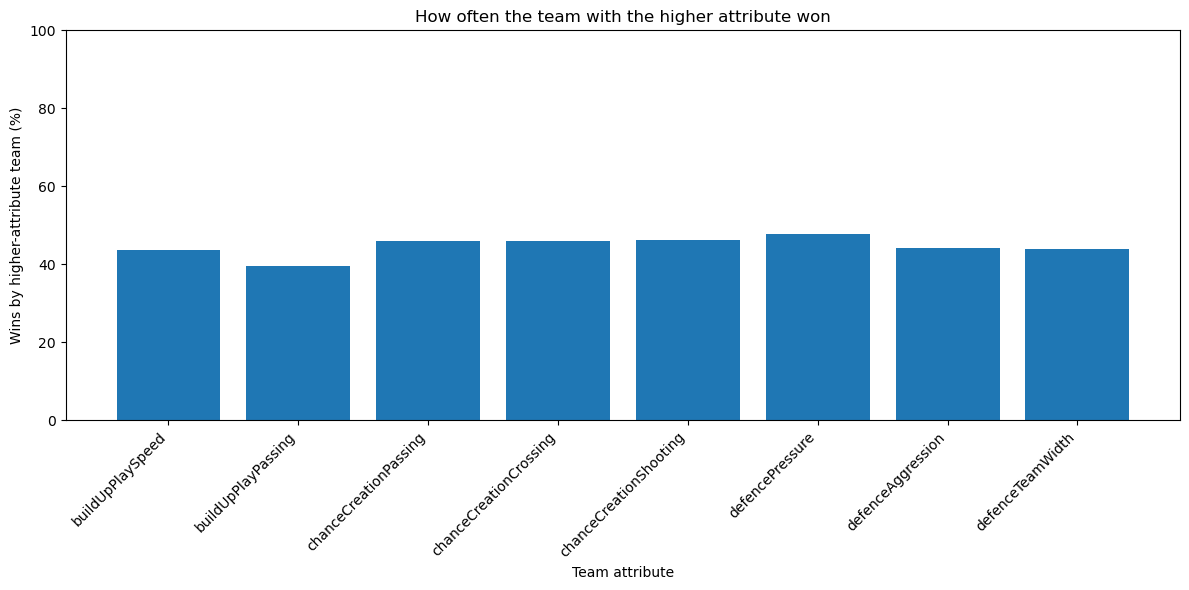

In [24]:

plt.figure(figsize=(12, 6))
plt.bar(results.index, results.values * 100)
plt.ylabel("Wins by higher-attribute team (%)")
plt.xlabel("Team attribute")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.title("How often the team with the higher attribute won")
plt.tight_layout()
plt.show()

In [ ]:
# Style the existing comparison chart
plt.style.use("seaborn-v0_8-whitegrid")

palette = [
    plt.cm.viridis(0.15 + i / max(len(plot_data) - 1, 1) * 0.75)
    for i in range(len(plot_data))
]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(
    plot_data["attribute"],
    plot_data["percentage"],
    color=palette,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title("How often the team with the higher attribute won", fontsize=16, fontweight="bold")
ax.set_xlabel("Team attribute", fontsize=12)
ax.set_ylabel("Higher-attribute team wins (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.axhline(50, color="gray", linestyle="--", linewidth=1.2)

ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)
ax.tick_params(axis="x", labelrotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

for bar, pct, matches in zip(bars, plot_data["percentage"], plot_data["matches"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{pct:.1f}%\n({matches:,})",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()